# Mạng Nơ-ron Hồi quy (RNN)

## 1. Giới thiệu về RNN

RNN là một loại mạng nơ-ron nhân tạo được thiết kế để xử lý *dữ liệu tuần tự* (sequential data), như chuỗi thời gian, văn bản, hoặc âm thanh. Điểm đặc biệt của RNN là khả năng "ghi nhớ" thông tin từ các bước trước đó nhờ cấu trúc vòng lặp.

### Tại sao cần RNN?

- Trong mạng nơ-ron truyền thống, mỗi đầu vào là độc lập, không có mối quan hệ với các đầu vào trước đó.
- Với RNN, thông tin từ bước trước được truyền sang bước hiện tại, cho phép học các mẫu trong chuỗi dữ liệu.

### Ứng dụng của RNN

- Dự đoán chuỗi thời gian (ví dụ: giá cổ phiếu).
- Xử lý ngôn ngữ tự nhiên (NLP): dịch máy, sinh văn bản.
- Nhận diện giọng nói.

## 2. Cấu trúc của RNN

RNN có một vòng lặp trong kiến trúc, cho phép trạng thái ẩn (hidden state) được cập nhật qua từng bước thời gian. Các thành phần cơ bản:

- **Đầu vào:** $x_t$ tại thời điểm $t$.
- **Trạng thái ẩn:** $h_t$, lưu trữ thông tin từ các bước trước.
- **Đầu ra:** $y_t$ tại thời điểm $t$.

### Sơ đồ cơ bản

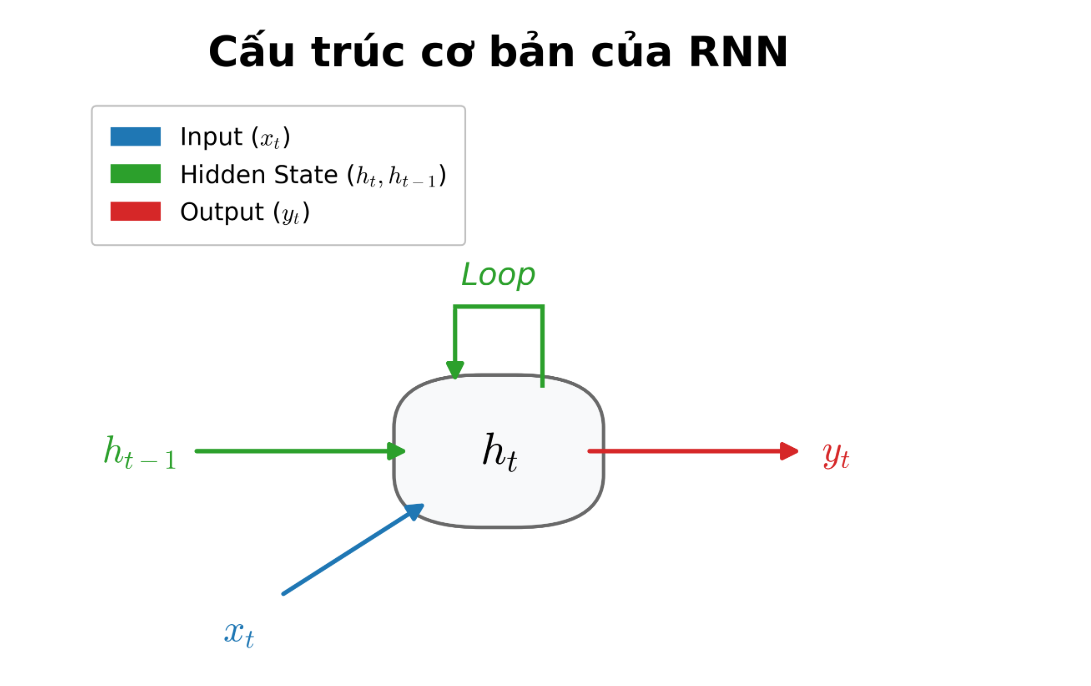


## 3. Công thức toán học của RNN

Trong RNN, tại mỗi thời điểm $t$, mô hình nhận đầu vào $x_t$, kết hợp với trạng thái ẩn từ bước trước $h_{t-1}$, rồi tạo ra trạng thái ẩn mới $h_t$. Từ trạng thái ẩn này, mô hình tiếp tục tính đầu ra $y_t$.

### 3.1. Công thức tính trạng thái ẩn

Trạng thái ẩn tại thời điểm $t$ được tính theo công thức:

$$
h_t = f(W_{xh}x_t + W_{hh}h_{t-1} + b_h)
$$

Trong đó:
- $x_t$: vector đầu vào tại thời điểm $t$
- $h_{t-1}$: trạng thái ẩn tại thời điểm trước đó
- $W_{xh}$: ma trận trọng số từ đầu vào đến trạng thái ẩn
- $W_{hh}$: ma trận trọng số hồi quy giữa trạng thái ẩn trước và trạng thái ẩn hiện tại
- $b_h$: vector bias của tầng ẩn
- $f$: hàm kích hoạt phi tuyến, thường là $\tanh$ hoặc sigmoid

Công thức trên cho thấy trạng thái ẩn mới được hình thành từ hai nguồn thông tin:
- thông tin hiện tại từ đầu vào $x_t$
- thông tin quá khứ được lưu trong trạng thái ẩn $h_{t-1}$

Nhờ cơ chế này, RNN có thể mô hình hóa dữ liệu tuần tự và duy trì ngữ cảnh theo thời gian.

#### Ví dụ minh họa

Giả sử:

$$
x_t = [0.5,\ 0.1]^T
$$

$$
h_{t-1} = [0.2,\ 0.3]^T
$$

và các tham số:

$$
W_{xh} =
\begin{bmatrix}
0.1 & 0.2 \\
0.3 & 0.4
\end{bmatrix}
$$

$$
W_{hh} =
\begin{bmatrix}
0.5 & 0.6 \\
0.7 & 0.8
\end{bmatrix}
$$

$$
b_h = [0.1,\ 0.2]^T
$$

Giả sử hàm kích hoạt là:

$$
f = \tanh
$$

Ta tính lần lượt:

**Bước 1: Thành phần từ đầu vào**

$$
W_{xh}x_t =
\begin{bmatrix}
0.1 & 0.2 \\
0.3 & 0.4
\end{bmatrix}
\begin{bmatrix}
0.5 \\
0.1
\end{bmatrix}
=
\begin{bmatrix}
0.1 \times 0.5 + 0.2 \times 0.1 \\
0.3 \times 0.5 + 0.4 \times 0.1
\end{bmatrix}
=
\begin{bmatrix}
0.07 \\
0.19
\end{bmatrix}
$$

**Bước 2: Thành phần từ trạng thái trước**

$$
W_{hh}h_{t-1} =
\begin{bmatrix}
0.5 & 0.6 \\
0.7 & 0.8
\end{bmatrix}
\begin{bmatrix}
0.2 \\
0.3
\end{bmatrix}
=
\begin{bmatrix}
0.5 \times 0.2 + 0.6 \times 0.3 \\
0.7 \times 0.2 + 0.8 \times 0.3
\end{bmatrix}
=
\begin{bmatrix}
0.28 \\
0.38
\end{bmatrix}
$$

**Bước 3: Cộng với bias**

$$
W_{xh}x_t + W_{hh}h_{t-1} + b_h
=
\begin{bmatrix}
0.07 \\
0.19
\end{bmatrix}
+
\begin{bmatrix}
0.28 \\
0.38
\end{bmatrix}
+
\begin{bmatrix}
0.1 \\
0.2
\end{bmatrix}
=
\begin{bmatrix}
0.45 \\
0.77
\end{bmatrix}
$$

**Bước 4: Áp dụng hàm $\tanh$**

$$
h_t = \tanh([0.45,\ 0.77]^T) \approx [0.422,\ 0.646]^T
$$

Vậy trạng thái ẩn tại thời điểm $t$ là:

$$
h_t \approx [0.422,\ 0.646]^T
$$

### 3.2. Công thức tính đầu ra

Sau khi có trạng thái ẩn $h_t$, đầu ra tại thời điểm $t$ được tính theo công thức:

$$
y_t = g(W_{hy}h_t + b_y)
$$

Trong đó:
- $W_{hy}$: ma trận trọng số từ trạng thái ẩn đến đầu ra
- $b_y$: bias của tầng đầu ra
- $g$: hàm kích hoạt đầu ra

Tùy bài toán, hàm $g$ có thể khác nhau:
- dùng sigmoid cho phân loại nhị phân
- dùng softmax cho phân loại nhiều lớp
- hoặc không dùng hàm kích hoạt nếu là bài toán hồi quy

#### Ví dụ tiếp nối

Giả sử:

$$
h_t = [0.422,\ 0.646]^T
$$

$$
W_{hy} = [0.9,\ 0.8]
$$

$$
b_y = 0.05
$$

và hàm kích hoạt đầu ra là sigmoid:

$$
g = \sigma
$$

Ta tính:

**Bước 1: Nhân trọng số với trạng thái ẩn**

$$
W_{hy}h_t = [0.9,\ 0.8]
\begin{bmatrix}
0.422 \\
0.646
\end{bmatrix}
= 0.9 \times 0.422 + 0.8 \times 0.646
= 0.3798 + 0.5168
= 0.8966
$$

**Bước 2: Cộng bias**

$$
0.8966 + 0.05 = 0.9466
$$

**Bước 3: Áp dụng hàm sigmoid**

$$
y_t = \sigma(0.9466) = \frac{1}{1 + e^{-0.9466}} \approx 0.720
$$

Vậy đầu ra của mô hình tại thời điểm $t$ là:

$$
y_t \approx 0.72
$$

### 3.3. Ý nghĩa của quá trình tính toán

Từ hai công thức trên, có thể thấy rằng RNN hoạt động theo cơ chế lặp qua từng bước thời gian:
1. nhận đầu vào mới $x_t$
2. kết hợp với thông tin đã lưu trong $h_{t-1}$
3. tạo ra trạng thái mới $h_t$
4. sinh đầu ra $y_t$

Nhờ đó, mô hình không chỉ dựa vào dữ liệu hiện tại mà còn tận dụng được ngữ cảnh từ các bước trước trong chuỗi. Đây là đặc điểm cốt lõi giúp RNN phù hợp với các bài toán xử lý dữ liệu tuần tự như văn bản, âm thanh và chuỗi thời gian.

## 4. Huấn luyện RNN (Backpropagation Through Time - BPTT)

RNN được huấn luyện bằng thuật toán **lan truyền ngược qua thời gian** (*Backpropagation Through Time - BPTT*).  
Ý tưởng chính là "mở" mạng RNN theo từng bước thời gian, sau đó áp dụng lan truyền ngược tương tự như trong mạng nơ-ron truyền thống, nhưng trên toàn bộ chuỗi.

Giả sử chuỗi có độ dài $T$, tổng hàm mất mát được tính như sau:

$$
L = \sum_{t=1}^{T} L_t
$$

Trong đó:
- $L_t$ là mất mát tại thời điểm $t$
- $T$ là số bước thời gian của chuỗi

Do trạng thái ẩn tại thời điểm hiện tại phụ thuộc vào các trạng thái trước đó, nên khi tính gradient, sai số không chỉ ảnh hưởng đến một thời điểm riêng lẻ mà còn lan truyền ngược qua nhiều bước thời gian trước đó. Vì vậy, quá trình huấn luyện RNN phức tạp hơn so với mạng nơ-ron truyền thẳng thông thường.

Về mặt trực quan, gradient đối với ma trận trọng số hồi quy $W_{hh}$ có thể được biểu diễn như sau:

$$
\frac{\partial L}{\partial W_{hh}} = \sum_{t=1}^{T} \frac{\partial L_t}{\partial W_{hh}}
$$

Điều này cho thấy trọng số $W_{hh}$ được chia sẻ qua tất cả các bước thời gian, nên gradient cuối cùng là tổng đóng góp từ toàn bộ chuỗi.

### Vấn đề gradient biến mất và gradient bùng nổ

Trong thực tế, RNN thường gặp hai vấn đề quan trọng khi huấn luyện trên chuỗi dài:

- **Gradient biến mất (vanishing gradient):** gradient trở nên rất nhỏ sau nhiều lần lan truyền ngược, làm mô hình khó học được các phụ thuộc dài hạn
- **Gradient bùng nổ (exploding gradient):** gradient tăng quá lớn, gây mất ổn định trong quá trình cập nhật trọng số

Đặc biệt, hiện tượng **gradient biến mất** là một trong những hạn chế lớn nhất của RNN cơ bản. Khi chuỗi đầu vào quá dài, thông tin từ các bước đầu chuỗi thường bị suy giảm đáng kể trước khi đến được các bước sau, khiến mô hình khó ghi nhớ ngữ cảnh xa.

Vì lý do đó, các kiến trúc như **LSTM** và **GRU** đã được đề xuất để cải thiện khả năng ghi nhớ thông tin dài hạn và giảm ảnh hưởng của hiện tượng gradient biến mất.

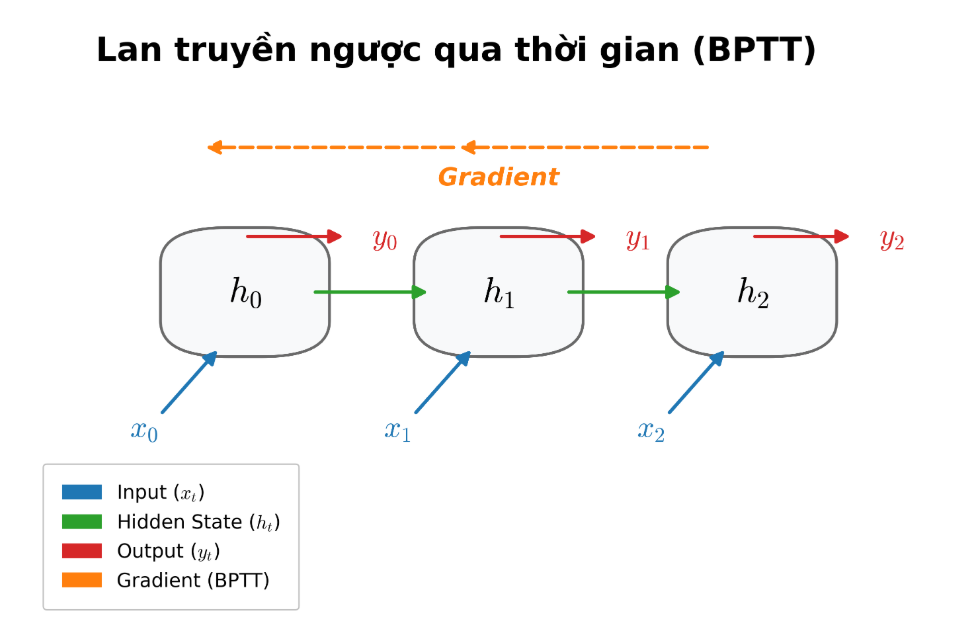

## 5. Ví dụ

Để dễ hình dung cách hoạt động của RNN, ta xét một ví dụ đơn giản trong bài toán dự đoán từ tiếp theo.

Giả sử chuỗi đầu vào là:

**"Tôi" $\rightarrow$ "thích"**

Mục tiêu của mô hình là dự đoán từ tiếp theo sau chuỗi này.  
Giả sử từ điển chỉ gồm ba từ:

- Tôi: $[1,0,0]$
- thích: $[0,1,0]$
- học: $[0,0,1]$

Tại bước thời gian thứ nhất, mô hình nhận từ **"Tôi"** dưới dạng vector one-hot $[1,0,0]$.  
Tại bước thời gian thứ hai, mô hình nhận từ **"thích"** dưới dạng vector $[0,1,0]$.  
Sau khi cập nhật trạng thái ẩn qua hai bước thời gian, RNN tạo ra đầu ra tại bước thứ hai để dự đoán từ tiếp theo.

Giả sử đầu ra của mô hình tại thời điểm đó là:

$$
y_2 = [0.1, 0.2, 0.7]
$$

Vector này có thể được hiểu là xác suất dự đoán cho ba từ trong từ điển.  
Trong đó:
- xác suất từ **"Tôi"** là $0.1$
- xác suất từ **"thích"** là $0.2$
- xác suất từ **"học"** là $0.7$

Vì giá trị lớn nhất nằm ở vị trí của từ **"học"**, nên mô hình dự đoán từ tiếp theo là:

$$
\text{"học"}
$$

Ví dụ này cho thấy RNN không xử lý từng từ một cách độc lập, mà sử dụng thông tin từ các bước trước đó để đưa ra dự đoán ở bước hiện tại. Đây chính là điểm khác biệt quan trọng giữa RNN và mạng nơ-ron truyền thẳng thông thường.

## 6. So sánh RNN và Feedforward Neural Network

| **RNN**                | **Feedforward NN**     |
|------------------------|------------------------|
| Xử lý dữ liệu tuần tự  | Đầu vào độc lập        |
| Có trạng thái ẩn $h_t$ | Không có bộ nhớ        |

## 7. Gradient biến mất

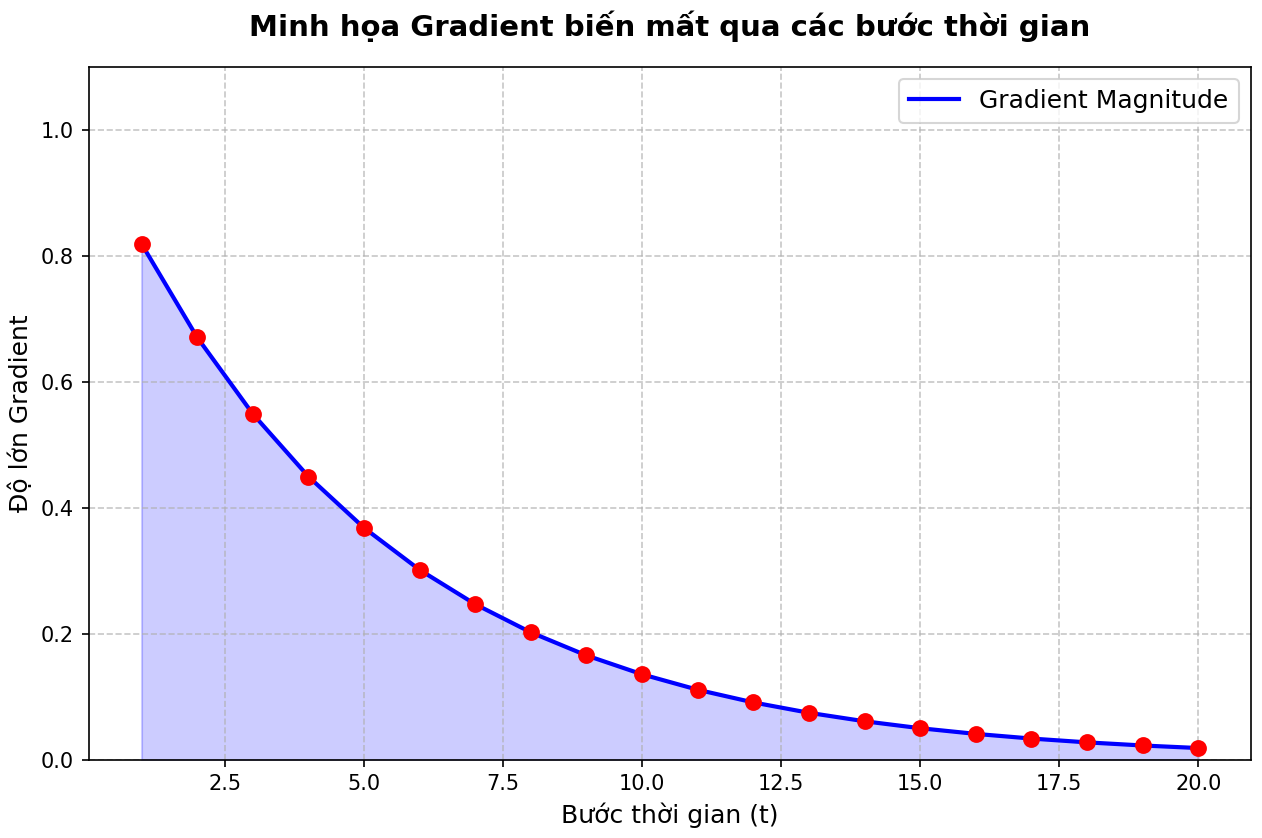


# BÀI THỰC HÀNH CƠ BẢN VỚI RNN

In [36]:
# Import các thư viện cần thiết
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [37]:
# 1. Chuẩn bị dữ liệu
# dữ liệu sin wave 
time_steps = 100
x = np.linspace(0, 20, time_steps)
data = np.sin(x) + 0.1 * np.random.randn(time_steps)

# Chuẩn hóa dữ liệu về khoảng [0, 1]
data = (data - data.min()) / (data.max() - data.min())

# Chuyển thành tensor PyTorch và thêm chiều batch
data = torch.FloatTensor(data).unsqueeze(1)  # Shape: [100, 1]

# Hàm tạo chuỗi con cho huấn luyện
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return torch.stack(X), torch.stack(y)

seq_length = 10  # Độ dài mỗi chuỗi
X, y = create_sequences(data, seq_length)  # X: [90, 10, 1], y: [90, 1]

In [38]:

# Chia 80% tập huấn luyện và 20% kiểm tra
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [39]:
# 2. Xây dựng mô hình RNN
class RNN(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, output_size=1):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden):
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out[:, -1, :])  # Lấy đầu ra của bước cuối cùng
        return out, hidden
    
    def init_hidden(self, batch_size):
        return torch.zeros(1, batch_size, self.hidden_size)
    
    def loss(self, predictions, targets):
        return nn.MSELoss()(predictions, targets)
    
    def adam_optimizer(self, learning_rate=0.001):
        return torch.optim.Adam(self.parameters(), lr=learning_rate)
    # lưu các giá trị train loss và valid loss
    def save_loss(self, train_loss, valid_loss):
        self.train_loss_history.append(train_loss)
        self.valid_loss_history.append(valid_loss)

In [40]:
# 2. Xây dựng mô hình RNN
class RNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=20, output_size=1):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden):
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out[:, -1, :])  # Lấy đầu ra của bước cuối cùng
        return out, hidden
    
    def init_hidden(self, batch_size):
        return torch.zeros(1, batch_size, self.hidden_size)

In [41]:
# Khởi tạo mô hình
model = RNN(input_size=1, hidden_size=20, output_size=1)

In [42]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [43]:
# 4. Huấn luyện mô hình
num_epochs = 100
batch_size = 16
loss_history = []
train_loss_history = []
val_loss_history = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    hidden = model.init_hidden(batch_size)
    
    # Tạo các batch ngẫu nhiên
    indices = torch.randperm(len(X_train))[:batch_size]
    X_batch = X_train[indices]
    y_batch = y_train[indices]
    
    hidden = model.init_hidden(batch_size)
    
    output, hidden = model(X_batch, hidden)
    loss = criterion(output, y_batch)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    total_loss += loss.item()
    loss_history.append(total_loss)  # Lưu loss
    train_loss_history.append(loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}')

Epoch [10/100], Loss: 0.0554
Epoch [20/100], Loss: 0.0112
Epoch [30/100], Loss: 0.0051
Epoch [40/100], Loss: 0.0073
Epoch [50/100], Loss: 0.0036
Epoch [60/100], Loss: 0.0028
Epoch [70/100], Loss: 0.0025
Epoch [80/100], Loss: 0.0036
Epoch [90/100], Loss: 0.0027
Epoch [100/100], Loss: 0.0031


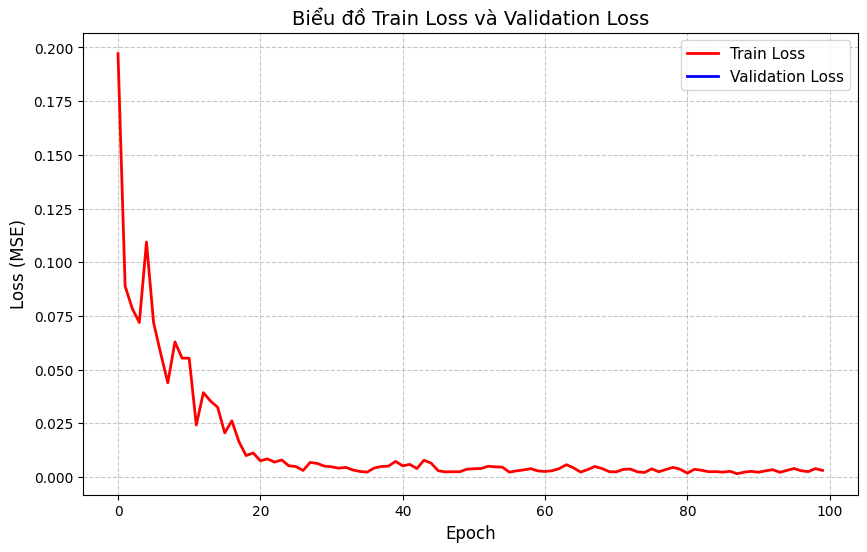

In [44]:
# Vẽ biểu đồ Train Loss và Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label="Train Loss", color='red', linewidth=2)
plt.plot(val_loss_history, label="Validation Loss", color='blue', linewidth=2)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss (MSE)", fontsize=12)
plt.title("Biểu đồ Train Loss và Validation Loss", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [45]:
# Đánh giá mô hình trên tập test
model.eval()
with torch.no_grad():
    hidden = model.init_hidden(X_test.size(0))
    test_predictions, _ = model(X_test, hidden)

# Tính các chỉ số đánh giá
from sklearn.metrics import mean_squared_error, mean_absolute_error

test_predictions_np = test_predictions.numpy()
y_test_np = y_test.numpy()

mse = mean_squared_error(y_test_np, test_predictions_np)
mae = mean_absolute_error(y_test_np, test_predictions_np)

print(f"\n=== KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ===")
print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"RMSE: {np.sqrt(mse):.6f}")


=== KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ===
MSE: 0.002581
MAE: 0.040373
RMSE: 0.050803


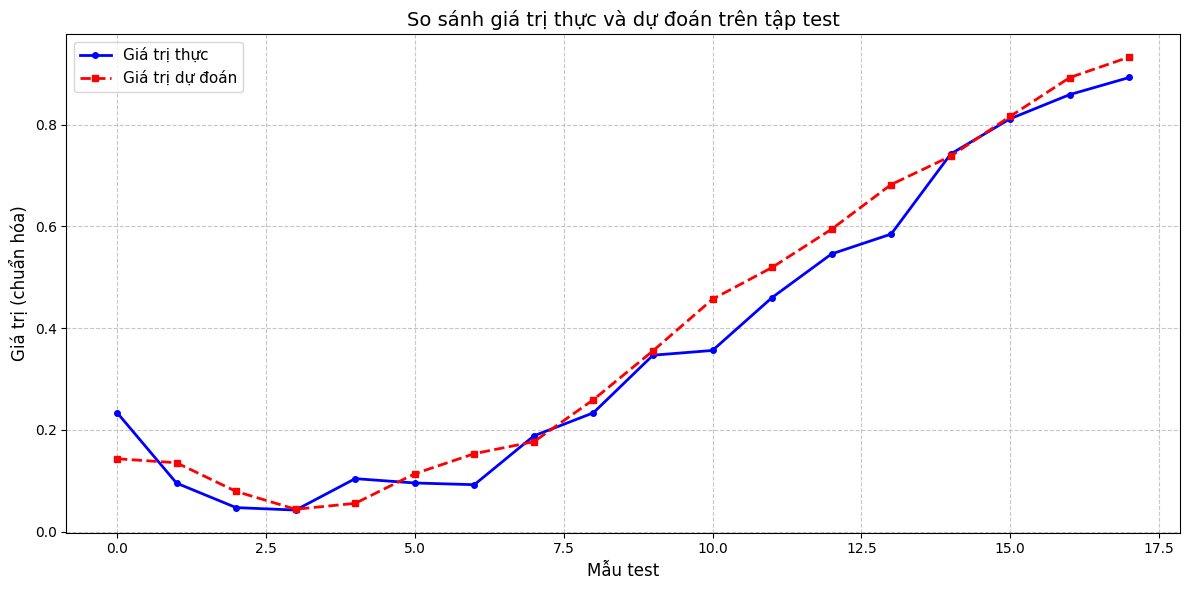

In [46]:
# Vẽ biểu đồ so sánh giá trị thực vs dự đoán trên tập test
plt.figure(figsize=(12, 6))
test_indices = np.arange(len(y_test_np))
plt.plot(test_indices, y_test_np, label='Giá trị thực', color='blue', linewidth=2, marker='o', markersize=4)
plt.plot(test_indices, test_predictions_np, label='Giá trị dự đoán', color='red', linestyle='--', linewidth=2, marker='s', markersize=4)
plt.title('So sánh giá trị thực và dự đoán trên tập test', fontsize=14)
plt.xlabel('Mẫu test', fontsize=12)
plt.ylabel('Giá trị (chuẩn hóa)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [47]:
# So sánh một số dự đoán trên tập test
print("\nMột số dự đoán chi tiết:")
print("-" * 60)
for i in range(min(5, len(y_test_np))):
    pred = test_predictions_np[i][0]
    actual = y_test_np[i][0]
    error = abs(pred - actual)
    print(f'Mẫu {i+1}: Dự đoán = {pred:.4f} | Thực tế = {actual:.4f} | Sai số = {error:.4f}')


Một số dự đoán chi tiết:
------------------------------------------------------------
Mẫu 1: Dự đoán = 0.1431 | Thực tế = 0.2340 | Sai số = 0.0909
Mẫu 2: Dự đoán = 0.1352 | Thực tế = 0.0951 | Sai số = 0.0401
Mẫu 3: Dự đoán = 0.0788 | Thực tế = 0.0470 | Sai số = 0.0318
Mẫu 4: Dự đoán = 0.0438 | Thực tế = 0.0422 | Sai số = 0.0016
Mẫu 5: Dự đoán = 0.0554 | Thực tế = 0.1040 | Sai số = 0.0486


# BÀI TẬP VỀ NHÀ

# Dự báo chuỗi thời gian bằng RNN

## Mô tả bài toán

Trong buổi học trên lớp, chúng ta đã làm quen với bài toán dự báo chuỗi thời gian bằng mô hình RNN trên dữ liệu sóng sin đơn giản.  
Để hiểu sâu hơn về cách hoạt động của mô hình và rèn luyện kỹ năng xử lý dữ liệu chuỗi, ở bài tập này em sẽ xây dựng một mô hình dự báo trên **dữ liệu đa biến**, phức tạp hơn so với ví dụ trên lớp.

Mục tiêu của bài là sử dụng các giá trị trong quá khứ của nhiều đặc trưng để dự đoán giá trị của biến mục tiêu ở thời điểm tiếp theo.

## Mục tiêu cần đạt

Sau khi hoàn thành bài tập, em cần:

- Biết cách tạo và xử lý dữ liệu chuỗi thời gian.
- Biết cách chuẩn hóa dữ liệu trước khi đưa vào mô hình.
- Biết cách tạo các chuỗi con phục vụ huấn luyện.
- Xây dựng được mô hình RNN bằng PyTorch.
- Thực hiện huấn luyện, đánh giá và trực quan hóa kết quả.

## Dữ liệu sử dụng

Khác với ví dụ trên lớp chỉ có một chuỗi sin, trong bài này dữ liệu gồm nhiều đặc trưng hơn:

- `feature_1`: chuỗi dạng sin
- `feature_2`: chuỗi dạng cos
- `feature_3`: chuỗi có xu hướng tăng nhẹ kèm nhiễu
- `target`: biến mục tiêu được tạo từ tổ hợp của các đặc trưng trên

   feature_1  feature_2  feature_3    target
0   0.000000   1.000000   0.049671  0.268485
1   0.100166   0.998742  -0.008810  0.319935
2   0.199325   0.994971   0.074802  0.450479
3   0.296479   0.988696   0.167353  0.508837
4   0.390650   0.979933  -0.003348  0.487590


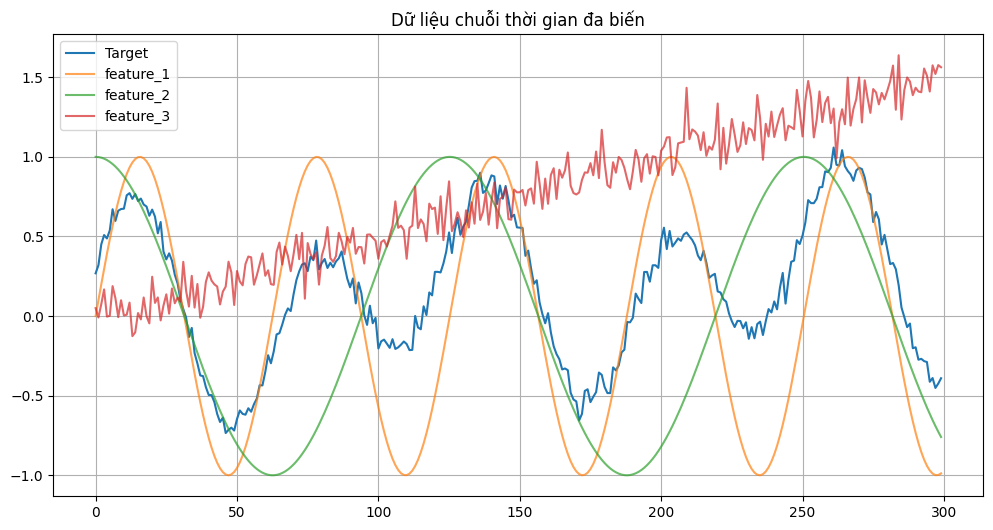

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

time_steps = 300
t = np.linspace(0, 30, time_steps)

feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)

target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)

df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target
})

print(df.head())

plt.figure(figsize=(12,6))
plt.plot(df['target'], label='Target')
plt.plot(df['feature_1'], label='feature_1', alpha=0.7)
plt.plot(df['feature_2'], label='feature_2', alpha=0.7)
plt.plot(df['feature_3'], label='feature_3', alpha=0.7)
plt.legend()
plt.title("Dữ liệu chuỗi thời gian đa biến")
plt.grid(True)
plt.show()

## Yêu cầu bài tập

### Phần 1. Tiền xử lý dữ liệu

Thực hiện các yêu cầu sau:

- Chuẩn hóa dữ liệu về khoảng `[0, 1]` hoặc dùng chuẩn hóa z-score.
- Tạo các chuỗi con với độ dài `seq_length = 20`.
- Chia dữ liệu theo tỉ lệ:
  - 70% cho tập huấn luyện
  - 15% cho tập validation
  - 15% cho tập kiểm tra

### Phần 2. Xây dựng mô hình RNN

Xây dựng mô hình RNN bằng PyTorch với cấu hình gợi ý như sau:

- `input_size = 3`
- `hidden_size = 32`
- `output_size = 1`

Yêu cầu trong quá trình huấn luyện:

- Sử dụng hàm mất mát `MSELoss`.
- Sử dụng bộ tối ưu `Adam`.
- Huấn luyện mô hình trong `150 epochs`.
- Lưu lại các giá trị sau:
  - `train loss`
  - `validation loss`

### Phần 3. Đánh giá mô hình

Sau khi huấn luyện xong, thực hiện các yêu cầu sau:

- Dự đoán trên tập test.
- Tính các chỉ số đánh giá:
  - `MSE`
  - `MAE`
- Vẽ biểu đồ so sánh:
  - giá trị thực
  - giá trị dự đoán

  ### Phần 4. Yêu cầu nâng cao

- Thử ít nhất **2 giá trị khác nhau của `seq_length`** (ví dụ: 10, 20, 30) và nhận xét xem độ dài chuỗi ảnh hưởng như thế nào đến kết quả dự đoán.
- Thay đổi số lượng **hidden_size** (ví dụ: 16, 32, 64) để so sánh hiệu quả của mô hình.
- Tăng số epoch huấn luyện và quan sát sự thay đổi của `train loss` và `validation loss`.
- Thử dự đoán **nhiều bước tiếp theo** (ví dụ: 3 bước hoặc 5 bước) thay vì chỉ dự đoán 1 bước.
- Sử dụng **dropout** hoặc tăng số tầng của mô hình RNN để kiểm tra xem mô hình có cải thiện hay không.
- Thay đổi **learning rate** của bộ tối ưu Adam và so sánh kết quả.
- Vẽ thêm biểu đồ thể hiện sai số dự đoán theo từng thời điểm trên tập test.
- Viết phần nhận xét ngắn về những yếu tố làm mô hình dự đoán tốt hơn hoặc kém hơn.

Deadline: 28/03/2026


In [49]:
# Phần 1: Tiền xử lý dữ liệu từ DataFrame
# Chuẩn hóa dữ liệu
from sklearn.preprocessing import MinMaxScaler

# Tách đặc trưng và mục tiêu
features = df[['feature_1', 'feature_2', 'feature_3']].values  # Shape: [300, 3]
target = df[['target']].values  # Shape: [300, 1]

# Chuẩn hóa về [0, 1]
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaler_target = MinMaxScaler(feature_range=(0, 1))

features_normalized = scaler_features.fit_transform(features)
target_normalized = scaler_target.fit_transform(target)

# Chuyển thành tensor PyTorch
features_tensor = torch.FloatTensor(features_normalized)
target_tensor = torch.FloatTensor(target_normalized)

print(f"Features shape: {features_tensor.shape}")
print(f"Target shape: {target_tensor.shape}")

Features shape: torch.Size([300, 3])
Target shape: torch.Size([300, 1])


In [50]:
# Hàm tạo chuỗi con cho dữ liệu đa biến
def create_sequences_multivariate(features, target, seq_length):
    """
    Tạo chuỗi con từ dữ liệu đa biến
    features: tensor [n_samples, n_features]
    target: tensor [n_samples, 1]
    seq_length: độ dài chuỗi
    """
    X, y = [], []
    for i in range(len(features) - seq_length):
        X.append(features[i:i + seq_length])  # [seq_length, 3]
        y.append(target[i + seq_length])      # [1]
    return torch.stack(X), torch.stack(y)

seq_length = 20
X, y = create_sequences_multivariate(features_tensor, target_tensor, seq_length)

print(f"X shape: {X.shape}")  # Nên là [n_sequences, 20, 3]
print(f"y shape: {y.shape}")  # Nên là [n_sequences, 1]

# Chia dữ liệu: 70% train, 15% val, 15% test
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

X_train, X_val, X_test = X[:train_size], X[train_size:train_size+val_size], X[train_size+val_size:]
y_train, y_val, y_test = y[:train_size], y[train_size:train_size+val_size], y[train_size+val_size:]

print(f"\nTrain set: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Val set: X_val {X_val.shape}, y_val {y_val.shape}")
print(f"Test set: X_test {X_test.shape}, y_test {y_test.shape}")

X shape: torch.Size([280, 20, 3])
y shape: torch.Size([280, 1])

Train set: X_train torch.Size([196, 20, 3]), y_train torch.Size([196, 1])
Val set: X_val torch.Size([42, 20, 3]), y_val torch.Size([42, 1])
Test set: X_test torch.Size([42, 20, 3]), y_test torch.Size([42, 1])


In [51]:
# 2. Xây dựng mô hình RNN
class RNN(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, output_size=1):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden):
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out[:, -1, :])  # Lấy đầu ra của bước cuối cùng
        return out, hidden
    
    def init_hidden(self, batch_size):
        return torch.zeros(1, batch_size, self.hidden_size)
    
    def loss(self, predictions, targets):
        return nn.MSELoss()(predictions, targets)
    
    def adam_optimizer(self, learning_rate=0.001):
        return torch.optim.Adam(self.parameters(), lr=learning_rate)
    

In [52]:
# Khởi tạo mô hình với input_size=3 (ba đặc trưng)
model = RNN(input_size=3, hidden_size=32, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [53]:
num_epochs = 150
batch_size = 16
train_loss_history = []
val_loss_history = []
train_accuracy_history = []  # Lưu trữ độ chính xác trên tập train

In [54]:
for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    total_train_accuracy = 0
    
    # Tạo các batch ngẫu nhiên từ tập huấn luyện
    indices = torch.randperm(len(X_train))
    
    for i in range(0, len(X_train), batch_size):
        batch_indices = indices[i:i+batch_size]
        X_batch = X_train[batch_indices]  # [batch_size, seq_length, 3]
        y_batch = y_train[batch_indices]  # [batch_size, 1]
        
        hidden = model.init_hidden(X_batch.size(0))
        
        output, hidden = model(X_batch, hidden)
        loss = criterion(output, y_batch)
        accuracy = ((output - y_batch).abs() < 0.05).float().mean().item()  # Ví dụ: dự đoán đúng nếu sai số < 0.05
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        total_train_accuracy += accuracy
    
    # Tính validation loss
    model.eval()
    with torch.no_grad():
        hidden = model.init_hidden(X_val.size(0))
        val_output, _ = model(X_val, hidden)
        val_loss = criterion(val_output, y_val)
    
    avg_train_loss = total_train_loss / max(1, len(X_train) // batch_size)
    avg_train_accuracy = total_train_accuracy / max(1, len(X_train) // batch_size)
    train_loss_history.append(avg_train_loss)
    train_accuracy_history.append(avg_train_accuracy)
    val_loss_history.append(val_loss.item())
    
    if (epoch + 1) % 15 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss.item():.4f}, train Accuracy: {avg_train_accuracy:.4f}')

Epoch [15/150], Train Loss: 0.0012, Val Loss: 0.0017, train Accuracy: 0.9323
Epoch [30/150], Train Loss: 0.0015, Val Loss: 0.0013, train Accuracy: 0.8958
Epoch [45/150], Train Loss: 0.0014, Val Loss: 0.0025, train Accuracy: 0.8802
Epoch [60/150], Train Loss: 0.0011, Val Loss: 0.0008, train Accuracy: 0.9427
Epoch [75/150], Train Loss: 0.0014, Val Loss: 0.0009, train Accuracy: 0.8802
Epoch [90/150], Train Loss: 0.0012, Val Loss: 0.0012, train Accuracy: 0.9323
Epoch [105/150], Train Loss: 0.0012, Val Loss: 0.0008, train Accuracy: 0.8906
Epoch [120/150], Train Loss: 0.0013, Val Loss: 0.0008, train Accuracy: 0.9323
Epoch [135/150], Train Loss: 0.0010, Val Loss: 0.0009, train Accuracy: 0.9688
Epoch [150/150], Train Loss: 0.0013, Val Loss: 0.0011, train Accuracy: 0.9167


In [55]:
model.eval()
with torch.no_grad():
    hidden = model.init_hidden(X_test.size(0))
    test_predictions, _ = model(X_test, hidden) 
    
from sklearn.metrics import mean_squared_error, mean_absolute_error
test_predictions_np = test_predictions.numpy()
y_test_np = y_test.numpy()

mse = mean_squared_error(y_test_np, test_predictions_np)
mae = mean_absolute_error(y_test_np, test_predictions_np)

print(f"MSE: {mse:.6f}")  
print(f"MAE: {mae:.6f}")
print(f"RMSE: {np.sqrt(mse):.6f}")  

MSE: 0.002078
MAE: 0.038265
RMSE: 0.045589


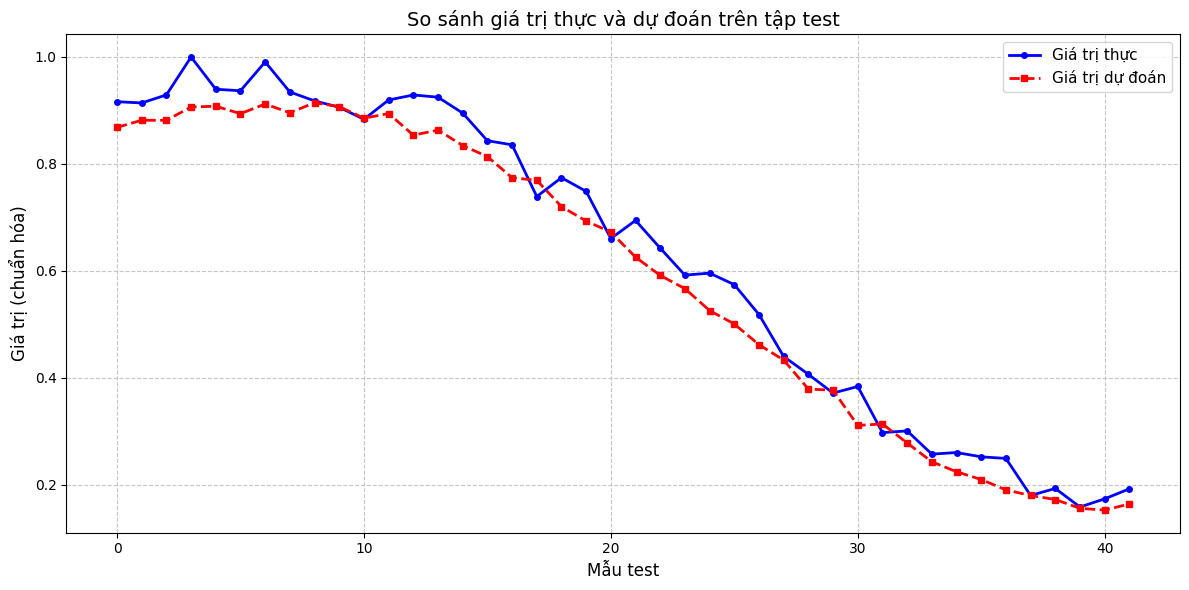

In [56]:
# Vẽ biểu đồ so sánh giá trị thực vs dự đoán trên tập test
plt.figure(figsize=(12, 6))
test_indices = np.arange(len(y_test_np))
plt.plot(test_indices, y_test_np, label='Giá trị thực', color='blue', linewidth=2, marker='o', markersize=4)
plt.plot(test_indices, test_predictions_np, label='Giá trị dự đoán', color='red', linestyle='--', linewidth=2, marker='s', markersize=4)
plt.title('So sánh giá trị thực và dự đoán trên tập test', fontsize=14)
plt.xlabel('Mẫu test', fontsize=12)
plt.ylabel('Giá trị (chuẩn hóa)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Phần 4

In [57]:
list_of_seglength = [10, 20, 30]
list_of_hidden_size = [16, 32, 64]

Epoch [15/150], Train Loss: 0.0011, Val Loss: 0.0011, train Accuracy: 0.9583
Epoch [30/150], Train Loss: 0.0011, Val Loss: 0.0011, train Accuracy: 0.9792
Epoch [45/150], Train Loss: 0.0011, Val Loss: 0.0017, train Accuracy: 0.9427
Epoch [60/150], Train Loss: 0.0010, Val Loss: 0.0008, train Accuracy: 0.9792
Epoch [75/150], Train Loss: 0.0010, Val Loss: 0.0008, train Accuracy: 0.9688
Epoch [90/150], Train Loss: 0.0012, Val Loss: 0.0007, train Accuracy: 0.9375
Epoch [105/150], Train Loss: 0.0012, Val Loss: 0.0009, train Accuracy: 0.9531
Epoch [120/150], Train Loss: 0.0010, Val Loss: 0.0009, train Accuracy: 0.9688
Epoch [135/150], Train Loss: 0.0009, Val Loss: 0.0008, train Accuracy: 0.9948
Epoch [150/150], Train Loss: 0.0010, Val Loss: 0.0012, train Accuracy: 1.0052

(seg_length=10, hidden_size=16)
MSE: 0.000794
MAE: 0.023413
RMSE: 0.028170


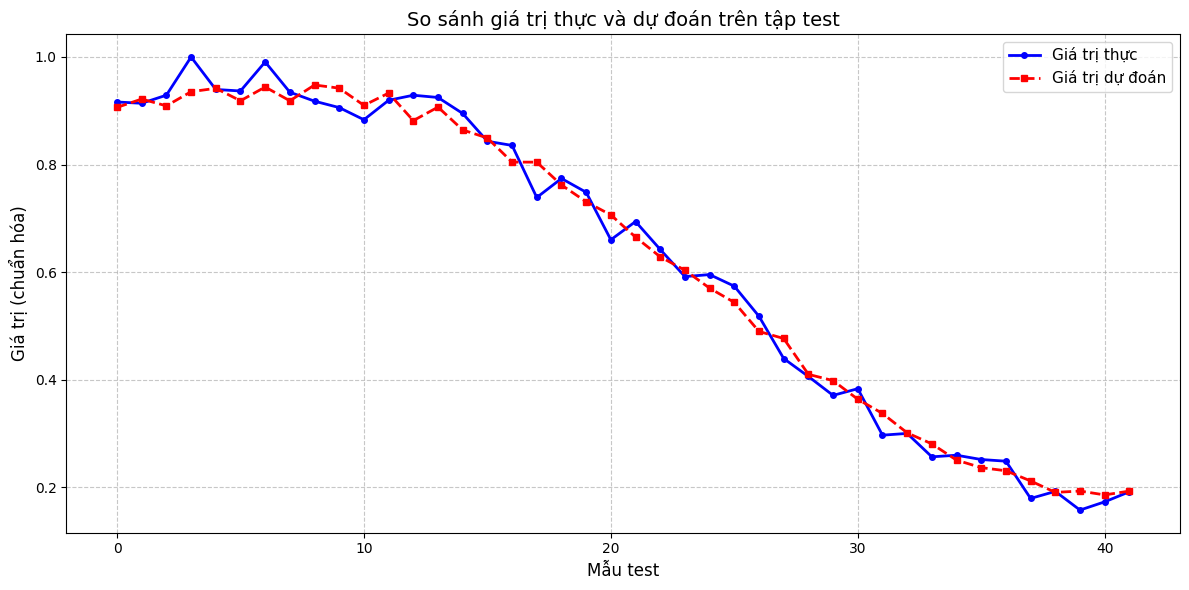

Epoch [15/150], Train Loss: 0.0010, Val Loss: 0.0011, train Accuracy: 0.9635
Epoch [30/150], Train Loss: 0.0011, Val Loss: 0.0010, train Accuracy: 0.9531
Epoch [45/150], Train Loss: 0.0388, Val Loss: 0.0185, train Accuracy: 0.1615
Epoch [60/150], Train Loss: 0.0016, Val Loss: 0.0051, train Accuracy: 0.8490
Epoch [75/150], Train Loss: 0.0018, Val Loss: 0.0010, train Accuracy: 0.8385
Epoch [90/150], Train Loss: 0.0018, Val Loss: 0.0011, train Accuracy: 0.8177
Epoch [105/150], Train Loss: 0.0012, Val Loss: 0.0029, train Accuracy: 0.9427
Epoch [120/150], Train Loss: 0.0013, Val Loss: 0.0011, train Accuracy: 0.9323
Epoch [135/150], Train Loss: 0.0012, Val Loss: 0.0037, train Accuracy: 0.9167
Epoch [150/150], Train Loss: 0.0016, Val Loss: 0.0011, train Accuracy: 0.8646

(seg_length=10, hidden_size=32)
MSE: 0.001397
MAE: 0.029044
RMSE: 0.037381


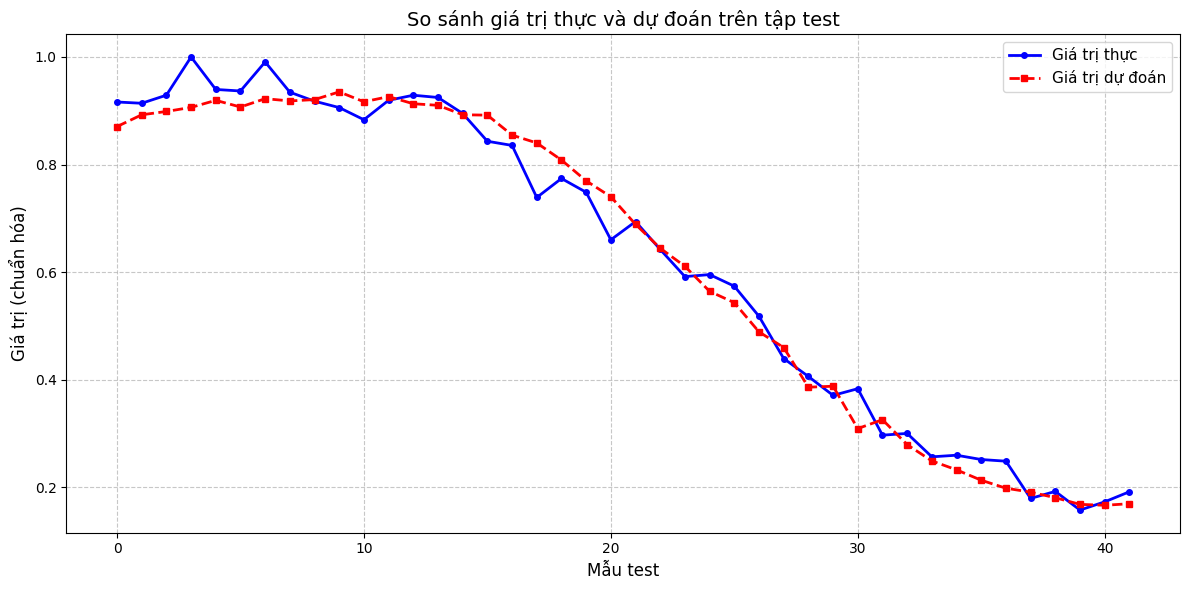

Epoch [15/150], Train Loss: 0.0020, Val Loss: 0.0022, train Accuracy: 0.7760
Epoch [30/150], Train Loss: 0.0011, Val Loss: 0.0012, train Accuracy: 0.9792
Epoch [45/150], Train Loss: 0.0011, Val Loss: 0.0021, train Accuracy: 0.9635
Epoch [60/150], Train Loss: 0.0013, Val Loss: 0.0008, train Accuracy: 0.9167
Epoch [75/150], Train Loss: 0.0016, Val Loss: 0.0009, train Accuracy: 0.8594
Epoch [90/150], Train Loss: 0.0027, Val Loss: 0.0008, train Accuracy: 0.7135
Epoch [105/150], Train Loss: 0.0014, Val Loss: 0.0008, train Accuracy: 0.8906
Epoch [120/150], Train Loss: 0.0011, Val Loss: 0.0008, train Accuracy: 0.9792
Epoch [135/150], Train Loss: 0.0032, Val Loss: 0.0019, train Accuracy: 0.6667
Epoch [150/150], Train Loss: 0.0018, Val Loss: 0.0038, train Accuracy: 0.8125

(seg_length=10, hidden_size=64)
MSE: 0.002589
MAE: 0.041726
RMSE: 0.050885


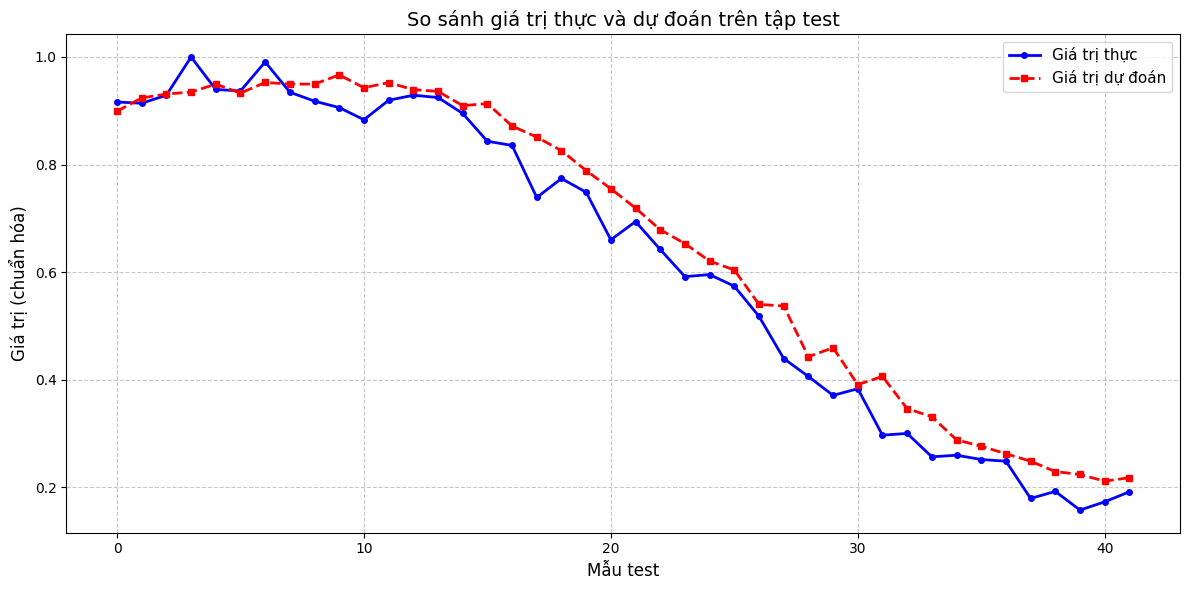

Epoch [15/150], Train Loss: 0.0026, Val Loss: 0.0015, train Accuracy: 0.7500
Epoch [30/150], Train Loss: 0.0013, Val Loss: 0.0009, train Accuracy: 0.9323
Epoch [45/150], Train Loss: 0.0029, Val Loss: 0.0009, train Accuracy: 0.6927
Epoch [60/150], Train Loss: 0.0018, Val Loss: 0.0009, train Accuracy: 0.8385
Epoch [75/150], Train Loss: 0.0015, Val Loss: 0.0021, train Accuracy: 0.9010
Epoch [90/150], Train Loss: 0.0026, Val Loss: 0.0010, train Accuracy: 0.7188
Epoch [105/150], Train Loss: 0.0014, Val Loss: 0.0019, train Accuracy: 0.9219
Epoch [120/150], Train Loss: 0.0011, Val Loss: 0.0011, train Accuracy: 0.9740
Epoch [135/150], Train Loss: 0.0012, Val Loss: 0.0020, train Accuracy: 0.9427
Epoch [150/150], Train Loss: 0.0011, Val Loss: 0.0016, train Accuracy: 0.9740

(seg_length=20, hidden_size=16)
MSE: 0.004124
MAE: 0.056809
RMSE: 0.064219


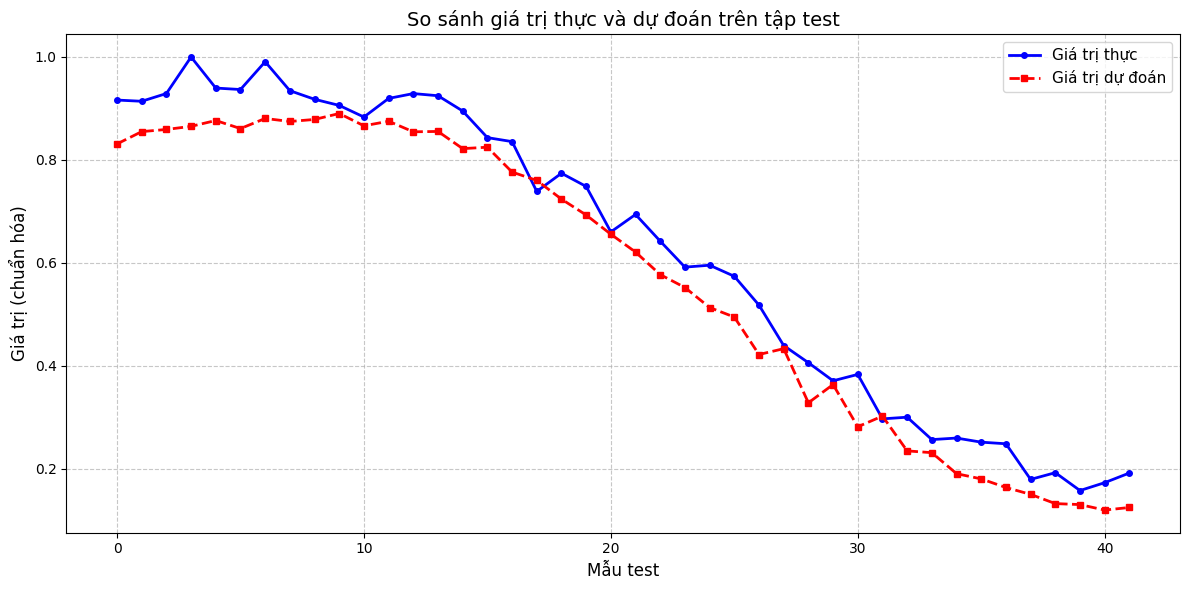

Epoch [15/150], Train Loss: 0.0015, Val Loss: 0.0016, train Accuracy: 0.8698
Epoch [30/150], Train Loss: 0.0013, Val Loss: 0.0023, train Accuracy: 0.9219
Epoch [45/150], Train Loss: 0.0014, Val Loss: 0.0011, train Accuracy: 0.9010
Epoch [60/150], Train Loss: 0.0019, Val Loss: 0.0011, train Accuracy: 0.7865
Epoch [75/150], Train Loss: 0.0014, Val Loss: 0.0016, train Accuracy: 0.9010
Epoch [90/150], Train Loss: 0.0013, Val Loss: 0.0019, train Accuracy: 0.9062
Epoch [105/150], Train Loss: 0.0029, Val Loss: 0.0014, train Accuracy: 0.6979
Epoch [120/150], Train Loss: 0.0016, Val Loss: 0.0063, train Accuracy: 0.8594
Epoch [135/150], Train Loss: 0.0021, Val Loss: 0.0018, train Accuracy: 0.7812
Epoch [150/150], Train Loss: 0.0014, Val Loss: 0.0012, train Accuracy: 0.8698

(seg_length=20, hidden_size=32)
MSE: 0.003101
MAE: 0.048180
RMSE: 0.055685


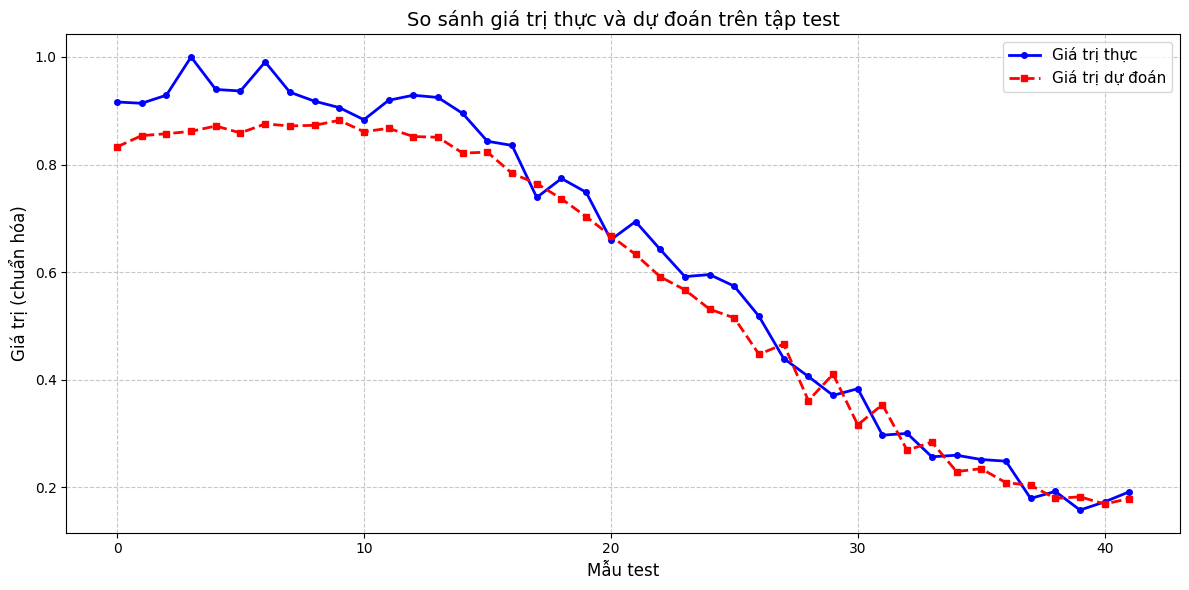

Epoch [15/150], Train Loss: 0.0030, Val Loss: 0.0013, train Accuracy: 0.6562
Epoch [30/150], Train Loss: 0.0017, Val Loss: 0.0016, train Accuracy: 0.8385
Epoch [45/150], Train Loss: 0.0020, Val Loss: 0.0044, train Accuracy: 0.8281
Epoch [60/150], Train Loss: 0.0016, Val Loss: 0.0012, train Accuracy: 0.8594
Epoch [75/150], Train Loss: 0.0013, Val Loss: 0.0013, train Accuracy: 0.9531
Epoch [90/150], Train Loss: 0.0014, Val Loss: 0.0021, train Accuracy: 0.8906
Epoch [105/150], Train Loss: 0.0010, Val Loss: 0.0012, train Accuracy: 0.9635
Epoch [120/150], Train Loss: 0.0020, Val Loss: 0.0013, train Accuracy: 0.8073
Epoch [135/150], Train Loss: 0.0027, Val Loss: 0.0038, train Accuracy: 0.6875
Epoch [150/150], Train Loss: 0.0016, Val Loss: 0.0010, train Accuracy: 0.8594

(seg_length=20, hidden_size=64)
MSE: 0.001978
MAE: 0.038064
RMSE: 0.044474


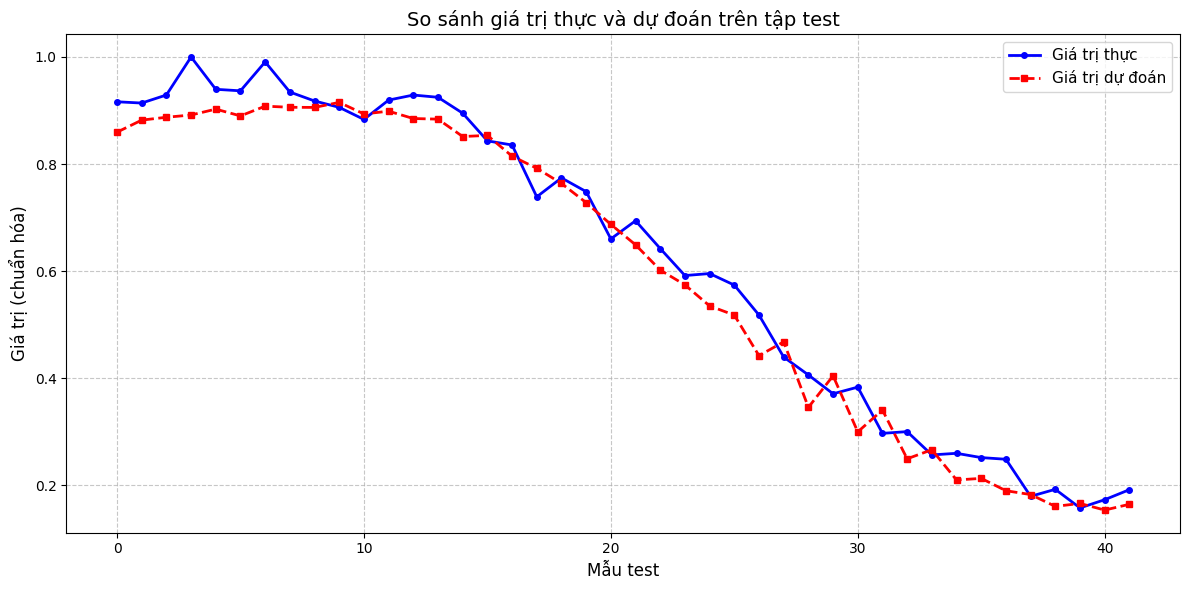

Epoch [15/150], Train Loss: 0.0022, Val Loss: 0.0011, train Accuracy: 0.7656
Epoch [30/150], Train Loss: 0.0016, Val Loss: 0.0011, train Accuracy: 0.8958
Epoch [45/150], Train Loss: 0.0014, Val Loss: 0.0016, train Accuracy: 0.8854
Epoch [60/150], Train Loss: 0.0014, Val Loss: 0.0013, train Accuracy: 0.9062
Epoch [75/150], Train Loss: 0.0014, Val Loss: 0.0013, train Accuracy: 0.8906
Epoch [90/150], Train Loss: 0.0011, Val Loss: 0.0012, train Accuracy: 0.9688
Epoch [105/150], Train Loss: 0.0020, Val Loss: 0.0016, train Accuracy: 0.7865
Epoch [120/150], Train Loss: 0.0018, Val Loss: 0.0013, train Accuracy: 0.8281
Epoch [135/150], Train Loss: 0.0017, Val Loss: 0.0014, train Accuracy: 0.8698
Epoch [150/150], Train Loss: 0.0011, Val Loss: 0.0020, train Accuracy: 0.9323

(seg_length=30, hidden_size=16)
MSE: 0.001352
MAE: 0.028926
RMSE: 0.036764


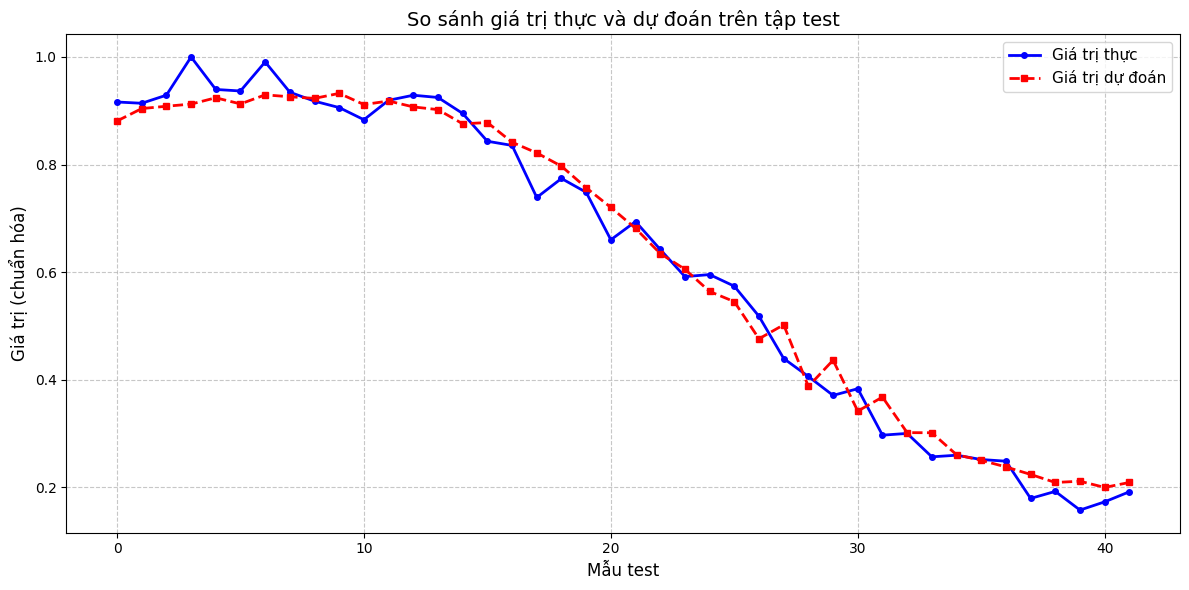

Epoch [15/150], Train Loss: 0.0029, Val Loss: 0.0153, train Accuracy: 0.6979
Epoch [30/150], Train Loss: 0.0017, Val Loss: 0.0020, train Accuracy: 0.8698
Epoch [45/150], Train Loss: 0.0019, Val Loss: 0.0013, train Accuracy: 0.8073
Epoch [60/150], Train Loss: 0.0015, Val Loss: 0.0030, train Accuracy: 0.9062
Epoch [75/150], Train Loss: 0.0012, Val Loss: 0.0013, train Accuracy: 0.9167
Epoch [90/150], Train Loss: 0.0019, Val Loss: 0.0034, train Accuracy: 0.8125
Epoch [105/150], Train Loss: 0.0016, Val Loss: 0.0015, train Accuracy: 0.8438
Epoch [120/150], Train Loss: 0.0021, Val Loss: 0.0025, train Accuracy: 0.7917
Epoch [135/150], Train Loss: 0.0021, Val Loss: 0.0021, train Accuracy: 0.7500
Epoch [150/150], Train Loss: 0.0019, Val Loss: 0.0014, train Accuracy: 0.8281

(seg_length=30, hidden_size=32)
MSE: 0.004306
MAE: 0.056206
RMSE: 0.065622


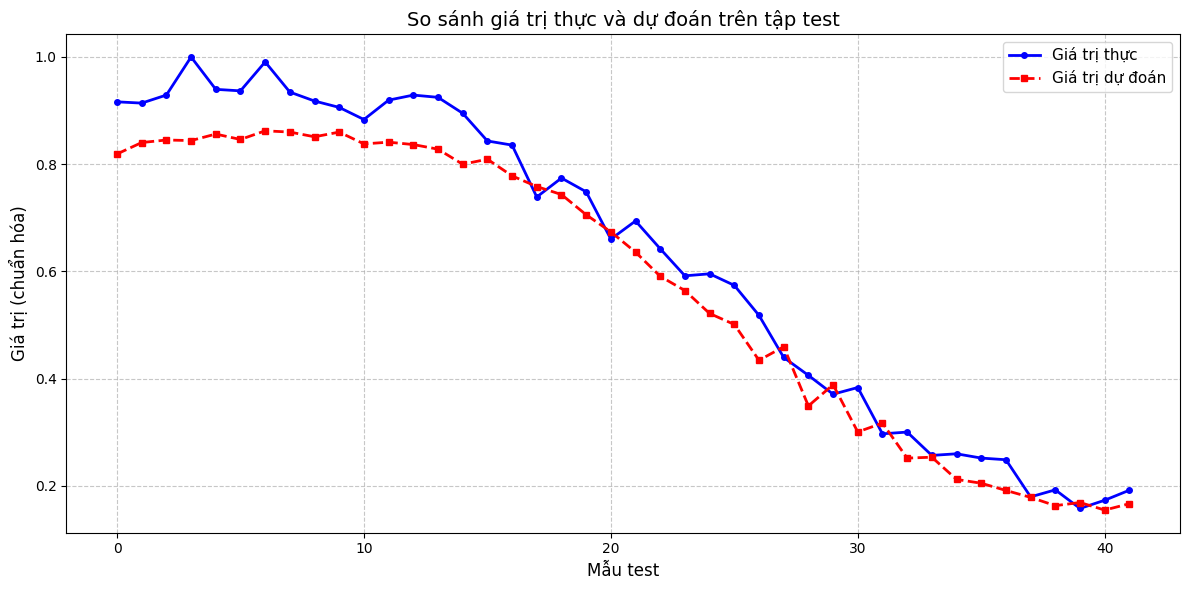

Epoch [15/150], Train Loss: 0.0011, Val Loss: 0.0011, train Accuracy: 0.9635
Epoch [30/150], Train Loss: 0.0018, Val Loss: 0.0041, train Accuracy: 0.8438
Epoch [45/150], Train Loss: 0.0014, Val Loss: 0.0011, train Accuracy: 0.9115
Epoch [60/150], Train Loss: 0.0014, Val Loss: 0.0012, train Accuracy: 0.9167
Epoch [75/150], Train Loss: 0.0267, Val Loss: 0.0080, train Accuracy: 0.3854
Epoch [90/150], Train Loss: 0.0029, Val Loss: 0.0028, train Accuracy: 0.6719
Epoch [105/150], Train Loss: 0.0022, Val Loss: 0.0010, train Accuracy: 0.7552
Epoch [120/150], Train Loss: 0.0023, Val Loss: 0.0046, train Accuracy: 0.7292
Epoch [135/150], Train Loss: 0.0026, Val Loss: 0.0021, train Accuracy: 0.7552
Epoch [150/150], Train Loss: 0.0015, Val Loss: 0.0014, train Accuracy: 0.9167

(seg_length=30, hidden_size=64)
MSE: 0.001465
MAE: 0.030280
RMSE: 0.038278


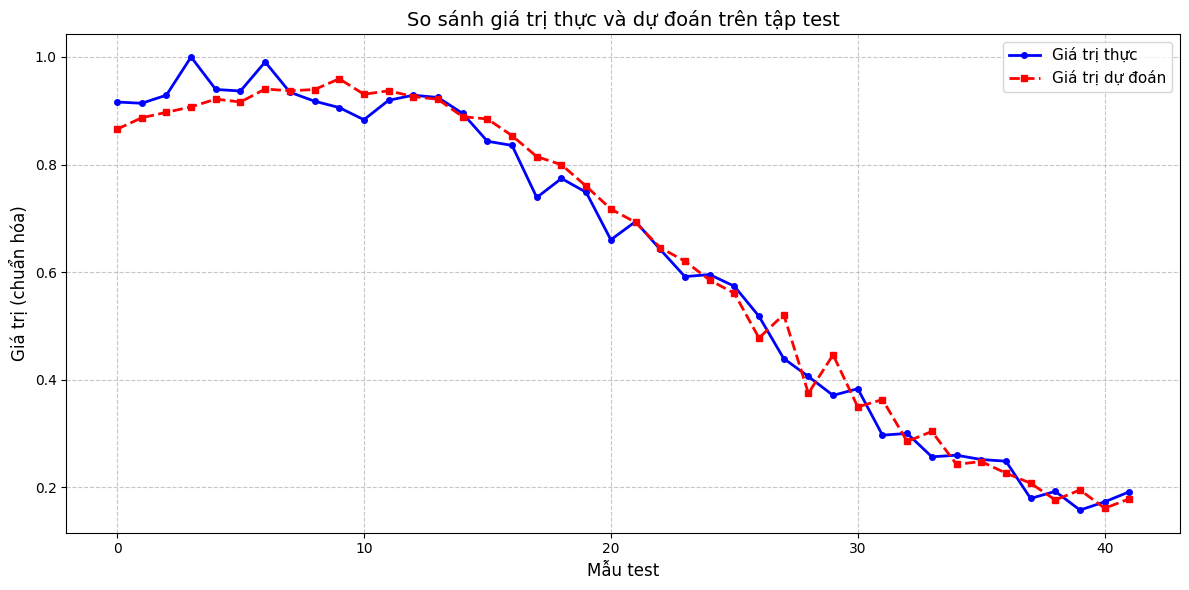

In [58]:
for seg_length in list_of_seglength:
    for hidden_size in list_of_hidden_size:
        for epoch in range(num_epochs):
            model.train()
            total_train_loss = 0
            total_train_accuracy = 0
            
            # Tạo các batch ngẫu nhiên từ tập huấn luyện
            indices = torch.randperm(len(X_train))
            
            for i in range(0, len(X_train), batch_size):
                batch_indices = indices[i:i+batch_size]
                X_batch = X_train[batch_indices]  # [batch_size, seq_length, 3]
                y_batch = y_train[batch_indices]  # [batch_size, 1]
                
                hidden = model.init_hidden(X_batch.size(0))
                
                output, hidden = model(X_batch, hidden)
                loss = criterion(output, y_batch)
                accuracy = ((output - y_batch).abs() < 0.05).float().mean().item()  # Ví dụ: dự đoán đúng nếu sai số < 0.05
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                total_train_loss += loss.item()
                total_train_accuracy += accuracy
            
            # Tính validation loss
            model.eval()
            with torch.no_grad():
                hidden = model.init_hidden(X_val.size(0))
                val_output, _ = model(X_val, hidden)
                val_loss = criterion(val_output, y_val)
            
            avg_train_loss = total_train_loss / max(1, len(X_train) // batch_size)
            avg_train_accuracy = total_train_accuracy / max(1, len(X_train) // batch_size)
            train_loss_history.append(avg_train_loss)
            train_accuracy_history.append(avg_train_accuracy)
            val_loss_history.append(val_loss.item())
            
            if (epoch + 1) % 15 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss.item():.4f}, train Accuracy: {avg_train_accuracy:.4f}')
             
        model.eval()
        with torch.no_grad():
            hidden = model.init_hidden(X_test.size(0))
            test_predictions, _ = model(X_test, hidden) 
            
        from sklearn.metrics import mean_squared_error, mean_absolute_error
        test_predictions_np = test_predictions.numpy()
        y_test_np = y_test.numpy()

        mse = mean_squared_error(y_test_np, test_predictions_np)
        mae = mean_absolute_error(y_test_np, test_predictions_np)

        print(f"\n(seg_length={seg_length}, hidden_size={hidden_size})")
        print(f"MSE: {mse:.6f}")  
        print(f"MAE: {mae:.6f}")
        print(f"RMSE: {np.sqrt(mse):.6f}")     
        
        # Vẽ biểu đồ so sánh giá trị thực vs dự đoán trên tập test
        plt.figure(figsize=(12, 6))
        test_indices = np.arange(len(y_test_np))
        plt.plot(test_indices, y_test_np, label='Giá trị thực', color='blue', linewidth=2, marker='o', markersize=4)
        plt.plot(test_indices, test_predictions_np, label='Giá trị dự đoán', color='red', linestyle='--', linewidth=2, marker='s', markersize=4)
        plt.title('So sánh giá trị thực và dự đoán trên tập test', fontsize=14)
        plt.xlabel('Mẫu test', fontsize=12)
        plt.ylabel('Giá trị (chuẩn hóa)', fontsize=12)
        plt.legend(fontsize=11)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()


In [59]:
list_of_epoch = [150, 210,325]

In [60]:
for epochs in list_of_epoch:
    print(f"Training with epochs={epochs}")
    
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        total_train_accuracy = 0
        
        # Tạo các batch ngẫu nhiên từ tập huấn luyện
        indices = torch.randperm(len(X_train))
        
        for i in range(0, len(X_train), epochs):
            batch_indices = indices[i:i+epochs]
            X_batch = X_train[batch_indices]  # [batch_size, seq_length, 3]
            y_batch = y_train[batch_indices]  # [batch_size, 1]
            
            hidden = model.init_hidden(X_batch.size(0))
            
            output, hidden = model(X_batch, hidden)
            loss = criterion(output, y_batch)
            accuracy = ((output - y_batch).abs() < 0.05).float().mean().item()  # Ví dụ: dự đoán đúng nếu sai số < 0.05
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item()
            total_train_accuracy += accuracy
        
        # Tính validation loss
        model.eval()
        with torch.no_grad():
            hidden = model.init_hidden(X_val.size(0))
            val_output, _ = model(X_val, hidden)
            val_loss = criterion(val_output, y_val)
        
        avg_train_loss = total_train_loss / max(1, len(X_train) // batch_size)
        avg_train_accuracy = total_train_accuracy / max(1, len(X_train) // batch_size)
        train_loss_history.append(avg_train_loss)
        train_accuracy_history.append(avg_train_accuracy)
        val_loss_history.append(val_loss.item())
        
        if (epoch + 1) % 15 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss.item():.4f}, train Accuracy: {avg_train_accuracy:.4f}')

Training with epochs=150
Epoch [15/150], Train Loss: 0.0002, Val Loss: 0.0012, train Accuracy: 0.1472
Epoch [30/150], Train Loss: 0.0002, Val Loss: 0.0011, train Accuracy: 0.1344
Epoch [45/150], Train Loss: 0.0002, Val Loss: 0.0012, train Accuracy: 0.1437
Epoch [60/150], Train Loss: 0.0002, Val Loss: 0.0012, train Accuracy: 0.1497
Epoch [75/150], Train Loss: 0.0002, Val Loss: 0.0013, train Accuracy: 0.1458
Epoch [90/150], Train Loss: 0.0002, Val Loss: 0.0014, train Accuracy: 0.1498
Epoch [105/150], Train Loss: 0.0002, Val Loss: 0.0012, train Accuracy: 0.1487
Epoch [120/150], Train Loss: 0.0002, Val Loss: 0.0012, train Accuracy: 0.1473
Epoch [135/150], Train Loss: 0.0002, Val Loss: 0.0014, train Accuracy: 0.1511
Epoch [150/150], Train Loss: 0.0002, Val Loss: 0.0012, train Accuracy: 0.1540
Training with epochs=210
Epoch [15/210], Train Loss: 0.0001, Val Loss: 0.0012, train Accuracy: 0.0757
Epoch [30/210], Train Loss: 0.0001, Val Loss: 0.0013, train Accuracy: 0.0765
Epoch [45/210], Train 

In [61]:
class RNN2(nn.Module):
    def __init__(self, input_size=3, hidden_size=64, output_size=3, num_layers=2, dropout=0.2):
        super(RNN2, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Thêm num_layers và dropout để tăng độ sâu và tránh overfitting
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers, 
                          batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden):
        # x shape: [batch_size, seq_length, input_size]
        out, hidden = self.rnn(x, hidden)
        # Lấy state cuối cùng: out[:, -1, :]
        out = self.fc(out[:, -1, :]) 
        return out, hidden
    
    def init_hidden(self, batch_size):
        # Khởi tạo hidden state cho tất cả các tầng
        return torch.zeros(self.num_layers, batch_size, self.hidden_size)

# Giả sử dự đoán 3 bước tiếp theo
output_steps = 3 
model = RNN2(input_size=3, hidden_size=64, output_size=output_steps, num_layers=2, dropout=0.2)

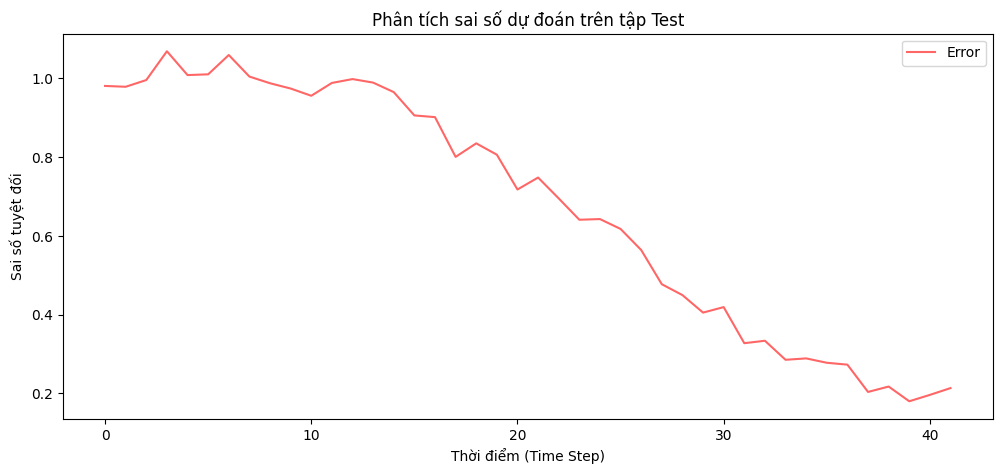

In [62]:
model.eval()
with torch.no_grad():
    hidden = model.init_hidden(X_test.size(0))
    predictions, _ = model(X_test, hidden)

    errors = torch.abs(predictions[:, 0] - y_test[:, 0]).numpy()
    
    plt.figure(figsize=(12, 5))
    plt.plot(errors, color='red', alpha=0.6, label='Error')
    plt.title("Phân tích sai số dự đoán trên tập Test")
    plt.xlabel("Thời điểm (Time Step)")
    plt.ylabel("Sai số tuyệt đối")
    plt.legend()
    plt.show()

Số tầng (Num Layers): Tăng số tầng giúp RNN học được các đặc trưng trừu tượng và phức tạp hơn trong dữ liệu chuỗi.

Dropout: Đây là kỹ thuật "cứu cánh" để chống Overfitting. Khi mô hình quá phức tạp so với lượng dữ liệu, Dropout giúp mô hình tổng quát hóa tốt hơn trên dữ liệu lạ (tập Test).

Dự báo đa bước (Multi-step): Việc dự báo 3-5 bước cùng lúc giúp mô hình nắm bắt được xu hướng (trend) dài hạn thay vì chỉ tập trung vào biến động tức thời của bước tiếp theo.

Learning Rate không phù hợp: Nếu quá cao, Loss sẽ nhảy loạn xạ (vấn đề nổ gradient). Nếu quá thấp, mô hình mãi không học xong.

Kích thước Batch: Batch quá nhỏ làm nhiễu quá trình cập nhật trọng số, trong khi batch quá lớn có thể làm giảm khả năng thoát khỏi các điểm tối ưu địa phương của mô hình.
